# 01 — Statistical Foundations for Machine Learning

> *A physicist's guide to the mathematics that underpins data science.*

This notebook builds every concept from first principles — definitions, derivations,
simulations, and real-data demonstrations on:

| Dataset | Source | Rows | Purpose |
|---|---|---|---|
| **Titanic** | `seaborn` | 891 | Categorical + numeric EDA |
| **California Housing** | `sklearn.datasets` | 20 640 | Continuous regression target |

Every section pairs **rigorous mathematical exposition** (with LaTeX) and **runnable code**
so you can verify each claim empirically.

---

## 1. Setup & Data Loading

We begin by importing the core scientific Python stack and loading both datasets.
A brief exploratory data analysis (EDA) gives us intuition before we formalise anything.

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Plotting defaults
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
    'figure.dpi': 100
})
sns.set_style("whitegrid")

np.random.seed(42)
print("✅ All imports successful.")

✅ All imports successful.


In [52]:
# --- Titanic ---
titanic = sns.load_dataset('titanic').dropna(subset=['age', 'fare'])
print(f"Titanic: {titanic.shape[0]} rows × {titanic.shape[1]} cols")
display(titanic.head())

# --- California Housing ---
cal_raw = fetch_california_housing(as_frame=True)
housing = cal_raw.frame
print(f"\nCalifornia Housing: {housing.shape[0]} rows × {housing.shape[1]} cols")
display(housing.head())

Titanic: 714 rows × 15 cols


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



California Housing: 20640 rows × 9 cols


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Quick EDA

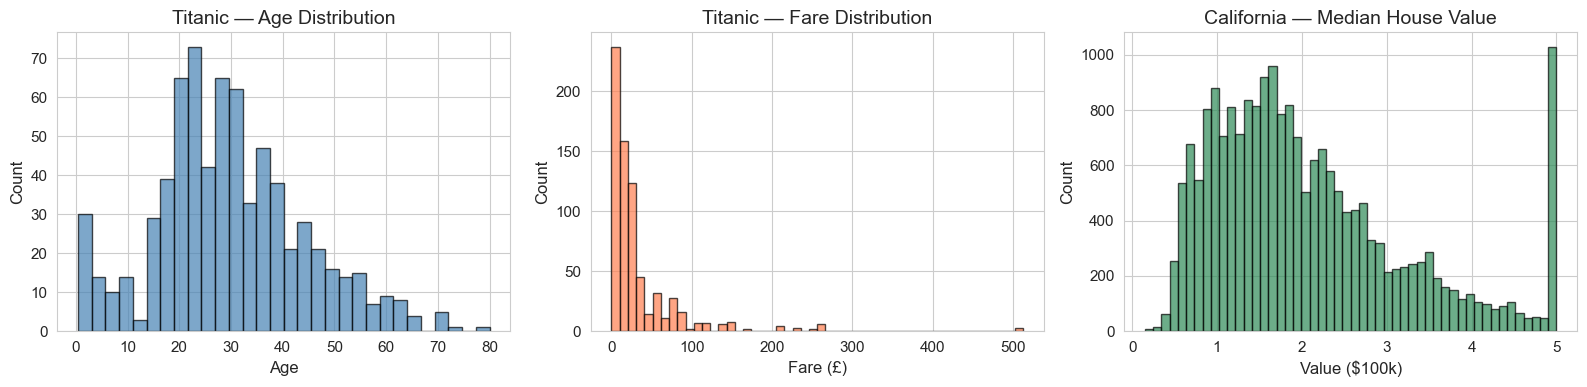

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Titanic age distribution
axes[0].hist(titanic['age'], bins=30, edgecolor='k', alpha=0.7, color='steelblue')
axes[0].set_title("Titanic — Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

# Titanic fare (log scale)
axes[1].hist(titanic['fare'], bins=50, edgecolor='k', alpha=0.7, color='coral')
axes[1].set_title("Titanic — Fare Distribution")
axes[1].set_xlabel("Fare (£)")
axes[1].set_ylabel("Count")

# Housing target
axes[2].hist(housing['MedHouseVal'], bins=50, edgecolor='k', alpha=0.7, color='seagreen')
axes[2].set_title("California — Median House Value")
axes[2].set_xlabel("Value ($100k)")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 2. Bar Notation: Sample Mean vs Population Mean

### The Fundamental Distinction

In statistics we sharply distinguish **population** parameters from **sample** statistics.

| Symbol | Meaning | Computable? |
|--------|---------|-------------|
| $\mu$ | Population mean — the *true* expected value | Rarely (need entire population) |
| $\bar{x}$ | Sample mean — arithmetic average of $n$ observed values | Always |

The **sample mean** is defined as

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

This is an *estimator* of $\mu$.  Two crucial properties:

1. **Unbiasedness**: $E[\bar{x}] = \mu$ — on average, $\bar{x}$ hits the target.
2. **Consistency**: as $n \to \infty$, $\bar{x} \xrightarrow{P} \mu$ (Law of Large Numbers).

### The Law of Large Numbers (LLN)

The **Weak LLN** states: for i.i.d. random variables $X_1, X_2, \dots$ with finite mean $\mu$,

$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i \xrightarrow{P} \mu \quad \text{as } n \to \infty$$

This is *why* averaging works: more data → better estimate.

> 💡 **Physicist's Intuition**: The LLN is the statistical analogue of a thermodynamic
> limit.  Just as macroscopic quantities (pressure, temperature) emerge deterministically
> from the chaotic motion of $\sim 10^{23}$ particles, $\bar{x}$ converges to $\mu$ as
> $n$ grows.  Fluctuations scale as $1/\sqrt{n}$.

> ⚠️ **Common Misconception**: The LLN does **not** say that a "run of bad luck" must be
> compensated by good luck (the Gambler's Fallacy).  Each draw is independent; convergence
> happens because new data *dilutes* old deviations, not because it *corrects* them.

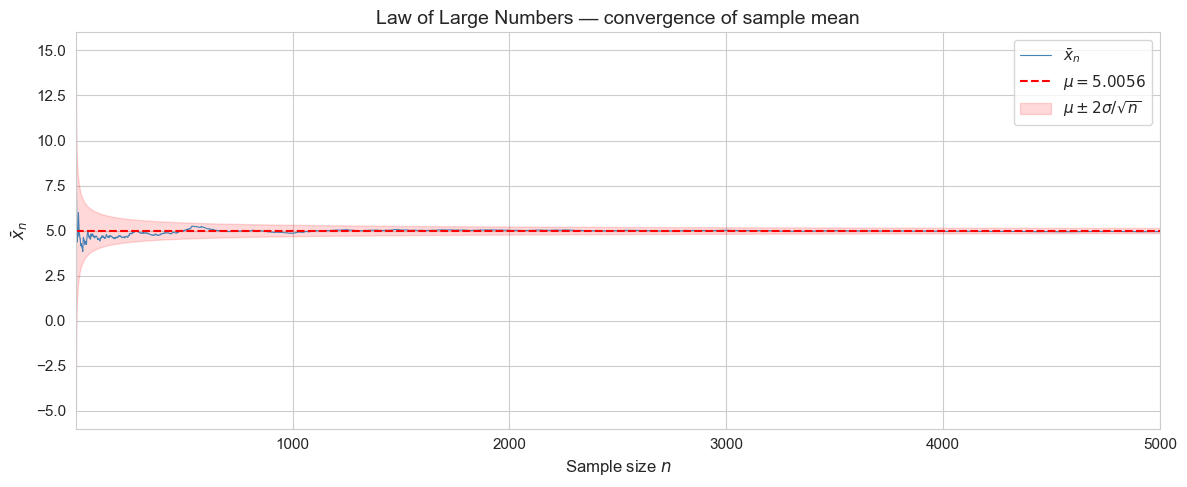

In [54]:
# Demonstrate LLN: sample mean converges to population mean
population = np.random.exponential(scale=5.0, size=1_000_000)
mu = population.mean()

sample_sizes = np.arange(1, 5001)
running_mean = np.cumsum(population[:5000]) / sample_sizes

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sample_sizes, running_mean, linewidth=0.8, color='steelblue', label=r'$\bar{x}_n$')
ax.axhline(mu, color='red', linestyle='--', linewidth=1.5, label=rf'$\mu = {mu:.4f}$')
ax.fill_between(sample_sizes,
                mu - 2 * np.sqrt(25 / sample_sizes),
                mu + 2 * np.sqrt(25 / sample_sizes),
                alpha=0.15, color='red', label=r'$\mu \pm 2\sigma/\sqrt{n}$')
ax.set_xlabel('Sample size $n$')
ax.set_ylabel(r'$\bar{x}_n$')
ax.set_title('Law of Large Numbers — convergence of sample mean')
ax.legend(fontsize=11)
ax.set_xlim(1, 5000)
plt.tight_layout()
plt.show()

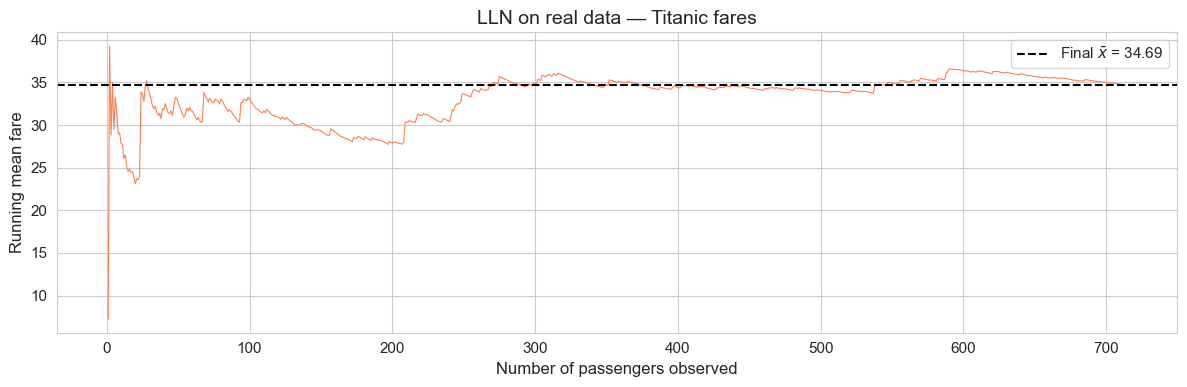

In [55]:
# Real data: running mean of Titanic fares
fares = titanic['fare'].values
n = len(fares)
running = np.cumsum(fares) / np.arange(1, n + 1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(1, n + 1), running, color='coral', linewidth=0.8)
ax.axhline(fares.mean(), color='k', linestyle='--', label=rf'Final $\bar{{x}}$ = {fares.mean():.2f}')
ax.set_xlabel('Number of passengers observed')
ax.set_ylabel('Running mean fare')
ax.set_title('LLN on real data — Titanic fares')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Hat Notation: Estimators and Predictions

### The "Hat" Convention

A **hat** ($\hat{\phantom{x}}$) over a symbol means *estimated from data* or *predicted*.

| Symbol | Meaning |
|--------|---------|
| $\theta$ | True (unknown) parameter |
| $\hat{\theta}$ | Estimator / estimate of $\theta$ |
| $y$ | True response value |
| $\hat{y}$ | Predicted response value |
| $\hat{\beta}$ | Estimated regression coefficient |

### Properties of Good Estimators

Let $\hat{\theta}_n$ be an estimator of $\theta$ based on $n$ observations.

1. **Unbiased**: $E[\hat{\theta}_n] = \theta$ for all $n$.
   The estimator hits the bullseye *on average*.

2. **Consistent**: $\hat{\theta}_n \xrightarrow{P} \theta$ as $n \to \infty$.
   With enough data, we *will* find the truth.

3. **Efficient**: Among all unbiased estimators, $\hat{\theta}$ has the smallest variance.
   It achieves the **Cramér–Rao lower bound**:

$$\text{Var}(\hat{\theta}) \geq \frac{1}{n \, I(\theta)}$$

where $I(\theta)$ is the Fisher information.

> 💡 **Physicist's Intuition**: Think of an estimator as a measurement apparatus.
> *Bias* is a systematic offset (like a miscalibrated thermometer).
> *Variance* is random noise (thermal fluctuations in the readout).
> A good instrument is both accurate (low bias) and precise (low variance).

> ⚠️ **Common Misconception**: "Unbiased is always best."  Not true!  Sometimes a slightly
> biased estimator with much lower variance gives a better MSE.  This is the **bias–variance
> tradeoff** — the foundation of regularisation (Ridge, LASSO).

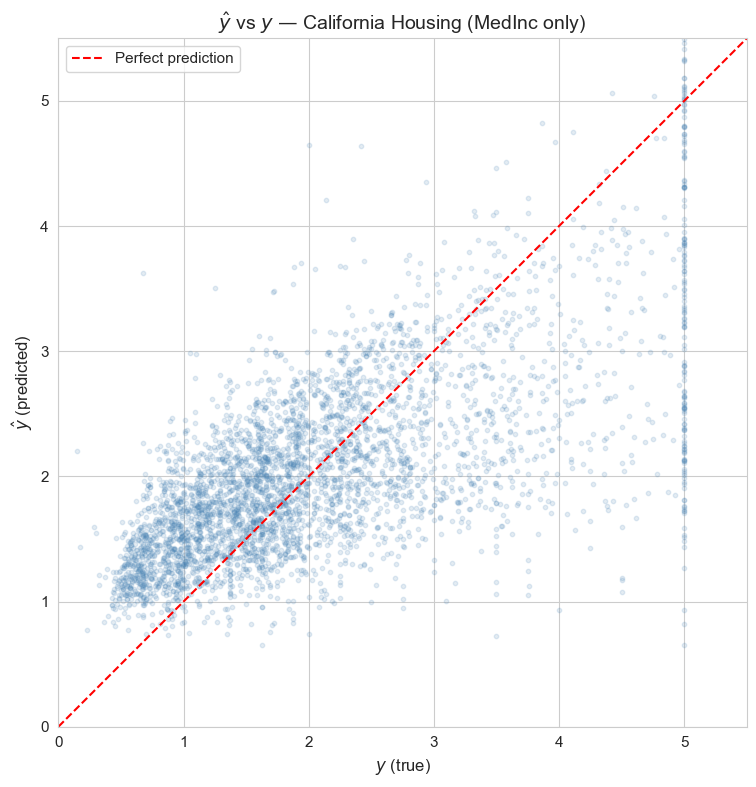

In [56]:
# Demonstrate ŷ vs y on California Housing
from sklearn.model_selection import train_test_split

X_housing = housing[['MedInc']].values
y_housing = housing['MedHouseVal'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

reg = LinearRegression().fit(X_train, y_train)
y_hat = reg.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_hat, alpha=0.15, s=10, color='steelblue')
lims = [0, 5.5]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('$y$ (true)')
ax.set_ylabel(r'$\hat{y}$ (predicted)')
ax.set_title(r'$\hat{y}$ vs $y$ — California Housing (MedInc only)')
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

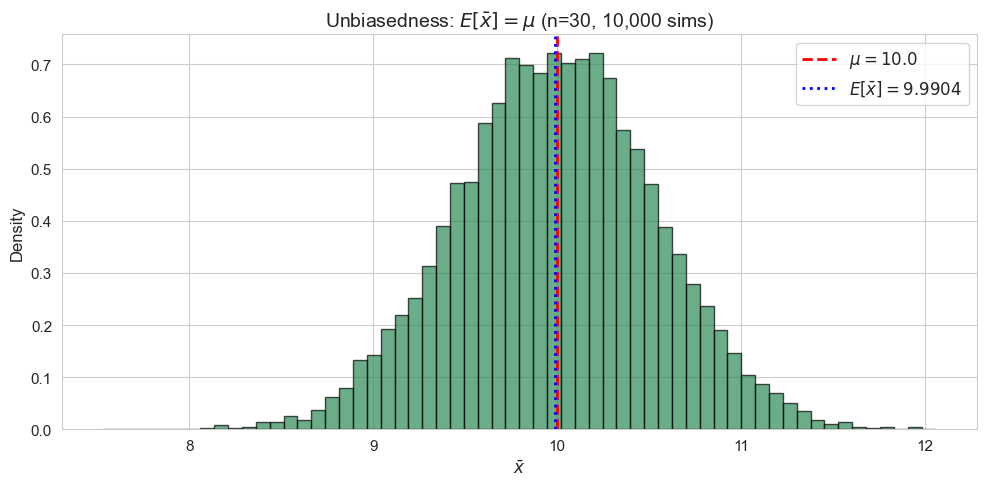

True μ       = 10.0
Mean of x̄'s  = 9.9904
Difference   = 0.0096


In [57]:
# Simulate unbiasedness of the sample mean
true_mu = 10.0
true_sigma = 3.0
n_obs = 30
n_simulations = 10_000

sample_means = np.array([
    np.random.normal(true_mu, true_sigma, n_obs).mean()
    for _ in range(n_simulations)
])

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sample_means, bins=60, density=True, alpha=0.7, color='seagreen', edgecolor='k')
ax.axvline(true_mu, color='red', linewidth=2, linestyle='--',
           label=rf'$\mu = {true_mu}$')
ax.axvline(sample_means.mean(), color='blue', linewidth=2, linestyle=':',
           label=rf'$E[\bar{{x}}] = {sample_means.mean():.4f}$')
ax.set_xlabel(r'$\bar{x}$')
ax.set_ylabel('Density')
ax.set_title(rf'Unbiasedness: $E[\bar{{x}}] = \mu$ (n={n_obs}, {n_simulations:,} sims)')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"True μ       = {true_mu}")
print(f"Mean of x̄'s  = {sample_means.mean():.4f}")
print(f"Difference   = {abs(sample_means.mean() - true_mu):.4f}")

## 4. Variance — Deep Dive

### Population Variance

For a random variable $X$ with mean $\mu$, the **variance** is the second central moment:

$$\sigma^2 = \text{Var}(X) = E\!\left[(X - \mu)^2\right] = E[X^2] - (E[X])^2$$

### Sample Variance and Bessel's Correction

Given observations $x_1, \dots, x_n$, the **sample variance** is

$$s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

**Why $n-1$ and not $n$?**

This is **Bessel's correction**, and the reason is subtle:

1. **Degrees of freedom**: We used the data once to compute $\bar{x}$.  This "uses up" one
   degree of freedom, leaving only $n-1$ independent deviations $(x_i - \bar{x})$.

2. **The sample mean is *too close* to the data**: $\bar{x}$ minimises
   $\sum(x_i - c)^2$ over all $c$.  So $\sum(x_i - \bar{x})^2 < \sum(x_i - \mu)^2$
   (unless $\bar{x} = \mu$ exactly).  Dividing by $n$ would systematically
   *underestimate* $\sigma^2$.

3. **Proof of unbiasedness**: One can show

$$E\!\left[\frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})^2\right] = \sigma^2$$

### Variance of the Sample Mean

$$\text{Var}(\bar{x}) = \frac{\sigma^2}{n}$$

The **standard error of the mean (SEM)** is

$$\text{SEM} = \frac{s}{\sqrt{n}}$$

> 💡 **Physicist's Intuition**: Variance is the *moment of inertia* of a probability
> distribution about its mean.  Just as $I = \int r^2 \, dm$ measures how "spread out" mass
> is from an axis, $\sigma^2 = \int (x - \mu)^2 f(x) \, dx$ measures how spread out
> probability is from $\mu$.

> ⚠️ **Common Misconception**: "Standard deviation is the average distance from the
> mean."  It's actually the *root-mean-square* distance, which over-weights outliers.
> The average absolute deviation $E[|X - \mu|]$ is a different (and often smaller)
> quantity.

In [58]:
# Simulate: variance with n vs n-1 divisor
true_var = 9.0  # σ² = 9, σ = 3
true_mu = 0.0
n_obs = 10
n_sims = 50_000

biased_vars = []
unbiased_vars = []

for _ in range(n_sims):
    sample = np.random.normal(true_mu, np.sqrt(true_var), n_obs)
    xbar = sample.mean()
    ss = np.sum((sample - xbar)**2)
    biased_vars.append(ss / n_obs)         # divide by n
    unbiased_vars.append(ss / (n_obs - 1)) # divide by n-1

print(f"True σ²                   = {true_var}")
print(f"E[biased estimator  /n ]  = {np.mean(biased_vars):.4f}  (biased low)")
print(f"E[unbiased estimator/n-1] = {np.mean(unbiased_vars):.4f}  (unbiased ✓)")
print(f"\nBias of /n estimator      = {np.mean(biased_vars) - true_var:.4f}")
print(f"Bias of /n-1 estimator    = {np.mean(unbiased_vars) - true_var:.4f}")

True σ²                   = 9.0
E[biased estimator  /n ]  = 8.1327  (biased low)
E[unbiased estimator/n-1] = 9.0363  (unbiased ✓)

Bias of /n estimator      = -0.8673
Bias of /n-1 estimator    = 0.0363


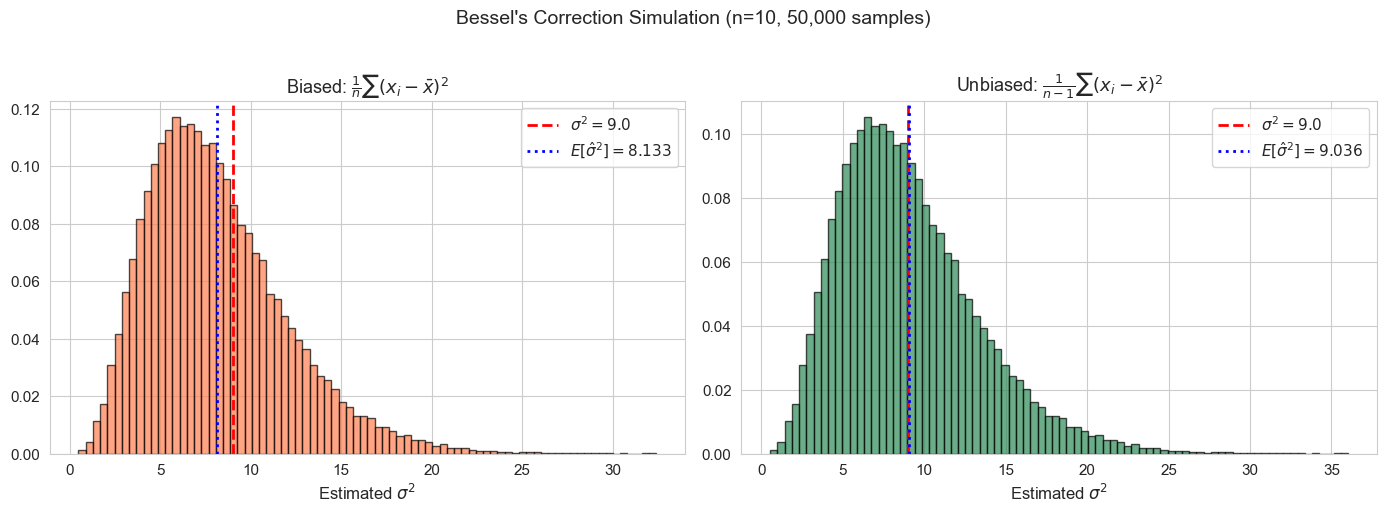

In [59]:
# Visualise the two estimators
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title, color in zip(
    axes,
    [biased_vars, unbiased_vars],
    [r'Biased: $\frac{1}{n}\sum(x_i-\bar{x})^2$',
     r'Unbiased: $\frac{1}{n-1}\sum(x_i-\bar{x})^2$'],
    ['coral', 'seagreen']
):
    ax.hist(data, bins=80, density=True, alpha=0.7, color=color, edgecolor='k')
    ax.axvline(true_var, color='red', linewidth=2, linestyle='--', label=rf'$\sigma^2 = {true_var}$')
    ax.axvline(np.mean(data), color='blue', linewidth=2, linestyle=':',
               label=rf'$E[\hat{{\sigma}}^2] = {np.mean(data):.3f}$')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(r'Estimated $\sigma^2$')
    ax.legend(fontsize=11)

plt.suptitle(f"Bessel's Correction Simulation (n={n_obs}, {n_sims:,} samples)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

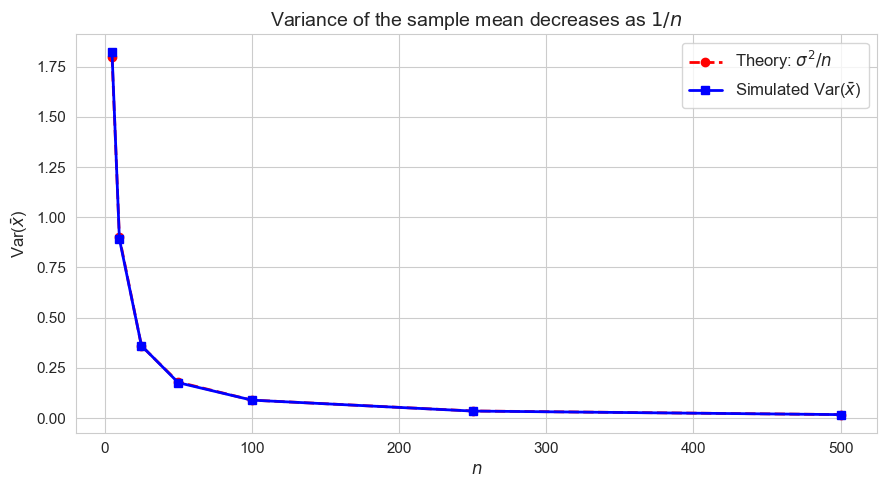

In [60]:
# Var(x̄) = σ²/n  — demonstrate with simulation
sample_sizes = [5, 10, 25, 50, 100, 250, 500]
true_sigma2 = 9.0

var_of_means = []
theoretical = []

for n in sample_sizes:
    means = [np.random.normal(0, 3, n).mean() for _ in range(20_000)]
    var_of_means.append(np.var(means))
    theoretical.append(true_sigma2 / n)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sample_sizes, theoretical, 'r--o', label=r'Theory: $\sigma^2/n$', linewidth=2)
ax.plot(sample_sizes, var_of_means, 'bs-', label=r'Simulated Var($\bar{x}$)', linewidth=2)
ax.set_xlabel('$n$')
ax.set_ylabel(r'Var($\bar{x}$)')
ax.set_title(r'Variance of the sample mean decreases as $1/n$')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 5. Covariance and Correlation

### Covariance

The **covariance** of two random variables $X$ and $Y$ is

$$\text{Cov}(X, Y) = E\!\left[(X - \mu_X)(Y - \mu_Y)\right] = E[XY] - E[X]E[Y]$$

* $\text{Cov}(X,Y) > 0$: $X$ and $Y$ tend to increase together.
* $\text{Cov}(X,Y) < 0$: one increases as the other decreases.
* $\text{Cov}(X,Y) = 0$: no *linear* relationship (but could still be dependent!).

### Pearson Correlation Coefficient

$$r = \frac{\text{Cov}(X,Y)}{\sigma_X \, \sigma_Y} = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2}\sqrt{\sum(y_i-\bar{y})^2}}$$

This is dimensionless and bounded: $-1 \leq r \leq 1$.

### Geometric Interpretation

If we centre the data (subtract means), $r$ is the **cosine of the angle** between
the data vectors $\mathbf{x}$ and $\mathbf{y}$ in $\mathbb{R}^n$:

$$r = \cos\theta = \frac{\mathbf{x} \cdot \mathbf{y}}{\|\mathbf{x}\| \, \|\mathbf{y}\|}$$

### Spearman Rank Correlation

Pearson $r$ measures *linear* association.  **Spearman's** $\rho$ replaces values with
their ranks and computes Pearson $r$ on the ranks — capturing *monotonic* relationships.

> 💡 **Physicist's Intuition**: Correlation is the normalised inner product of two
> signal vectors.  It's the same object as the overlap integral in quantum mechanics
> $\langle \psi | \phi \rangle / (\|\psi\|\|\phi\|)$ — measuring how "aligned" two
> states (here: variables) are.

> ⚠️ **Common Misconception**: "Correlation = 0 implies independence."  Only true for
> jointly Gaussian variables.  A parabolic relationship $Y = X^2$ gives $r = 0$ when
> $X$ is symmetric about zero, yet $Y$ is perfectly determined by $X$.

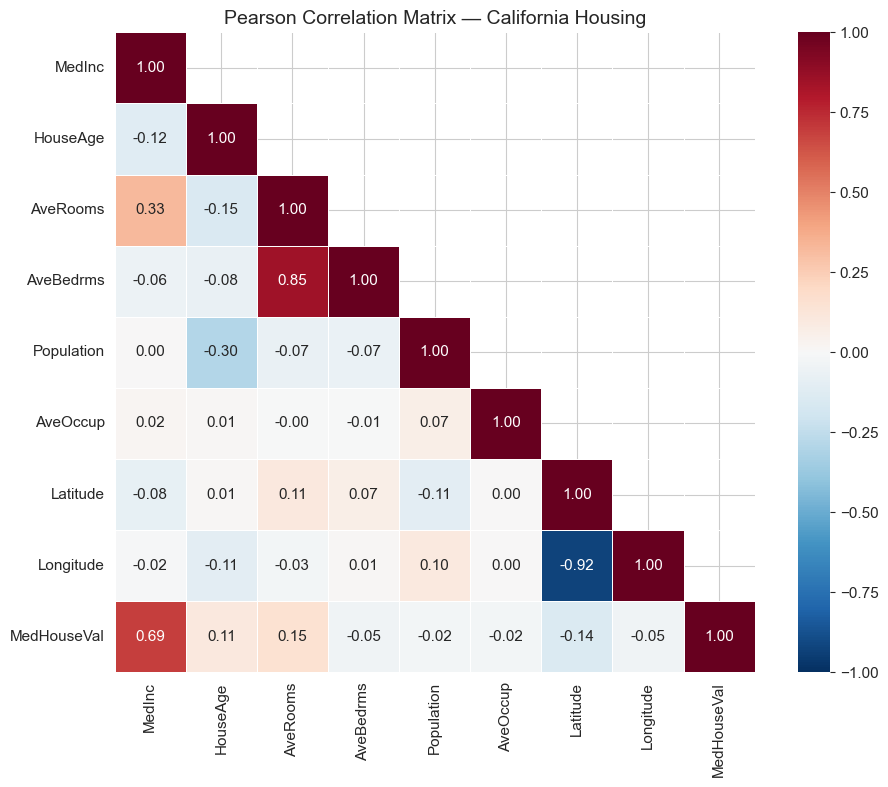

In [61]:
# Correlation matrix heatmap — California Housing
corr = housing.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax)
ax.set_title('Pearson Correlation Matrix — California Housing', fontsize=14)
plt.tight_layout()
plt.show()

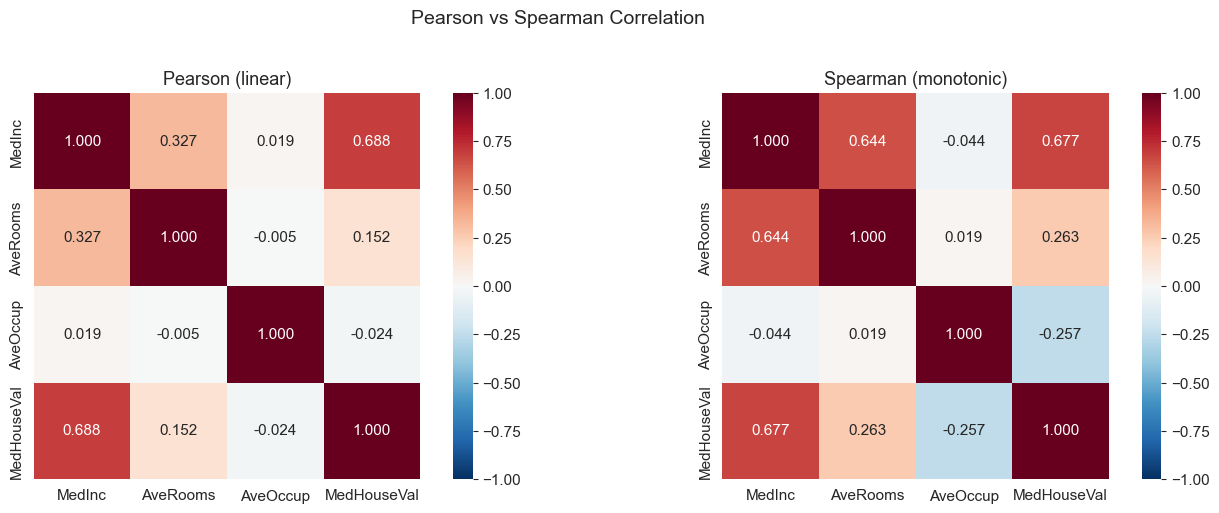

In [62]:
# Pearson vs Spearman on selected Housing features
features = ['MedInc', 'AveRooms', 'AveOccup', 'MedHouseVal']
pearson_corr = housing[features].corr(method='pearson')
spearman_corr = housing[features].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, corr_mat, title in zip(axes,
                                [pearson_corr, spearman_corr],
                                ['Pearson (linear)', 'Spearman (monotonic)']):
    sns.heatmap(corr_mat, annot=True, fmt='.3f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, square=True, ax=ax)
    ax.set_title(title, fontsize=13)

plt.suptitle('Pearson vs Spearman Correlation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [63]:
# Geometric interpretation: r = cos(θ)
x_centered = housing['MedInc'].values - housing['MedInc'].mean()
y_centered = housing['MedHouseVal'].values - housing['MedHouseVal'].mean()

cosine_angle = np.dot(x_centered, y_centered) / (np.linalg.norm(x_centered) * np.linalg.norm(y_centered))
pearson_r = np.corrcoef(housing['MedInc'], housing['MedHouseVal'])[0, 1]
angle_deg = np.degrees(np.arccos(np.clip(cosine_angle, -1, 1)))

print(f"Pearson r          = {pearson_r:.6f}")
print(f"cos(θ) from vectors = {cosine_angle:.6f}")
print(f"Angle θ            = {angle_deg:.2f}°")
print(f"\nThey match because r IS the cosine of the angle between centred data vectors.")

Pearson r          = 0.688075
cos(θ) from vectors = 0.688075
Angle θ            = 46.52°

They match because r IS the cosine of the angle between centred data vectors.


## 6. Simple Linear Regression

### The Model

$$y_i = \beta_0 + \beta_1 x_i + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2)$$

We observe $(x_i, y_i)$ for $i = 1, \dots, n$ and want to estimate $\beta_0, \beta_1$.

### Ordinary Least Squares (OLS)

We choose $\hat{\beta}_0, \hat{\beta}_1$ to minimise the **sum of squared residuals**:

$$\text{RSS} = \sum_{i=1}^n (y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i)^2$$

Taking $\partial \text{RSS}/\partial \hat{\beta}_1 = 0$ and
$\partial \text{RSS}/\partial \hat{\beta}_0 = 0$, we obtain:

$$\hat{\beta}_1 = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2}
              = \frac{\text{Cov}(X,Y)}{\text{Var}(X)}$$

$$\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$

Note that $\hat{\beta}_1 = r \cdot \frac{s_Y}{s_X}$ where $r$ is the Pearson correlation.

> 💡 **Physicist's Intuition**: OLS is a *projection*.  In the vector space of all possible
> $n$-vectors, $\hat{\mathbf{y}}$ is the orthogonal projection of $\mathbf{y}$ onto the
> column space of the design matrix $\mathbf{X}$.  The residuals $\mathbf{e} = \mathbf{y}
> - \hat{\mathbf{y}}$ are perpendicular to this subspace — exactly like decomposing a force
> into components parallel and perpendicular to a surface.

> ⚠️ **Common Misconception**: OLS does **not** assume $X$ is Gaussian, only that the
> *errors* $\varepsilon$ are (for inference).  The Gauss–Markov theorem guarantees OLS
> is BLUE even without normality — you just can't do hypothesis tests.

In [64]:
# Derive OLS coefficients by hand and compare with sklearn
x = housing['MedInc'].values
y = housing['MedHouseVal'].values
xbar, ybar = x.mean(), y.mean()

beta1_manual = np.sum((x - xbar) * (y - ybar)) / np.sum((x - xbar)**2)
beta0_manual = ybar - beta1_manual * xbar

# sklearn for comparison
reg_simple = LinearRegression().fit(x.reshape(-1, 1), y)

print("Manual OLS:")
print(f"  β̂₁ = {beta1_manual:.6f}")
print(f"  β̂₀ = {beta0_manual:.6f}")
print(f"\nsklearn OLS:")
print(f"  β̂₁ = {reg_simple.coef_[0]:.6f}")
print(f"  β̂₀ = {reg_simple.intercept_:.6f}")

Manual OLS:
  β̂₁ = 0.417938
  β̂₀ = 0.450856

sklearn OLS:
  β̂₁ = 0.417938
  β̂₀ = 0.450856


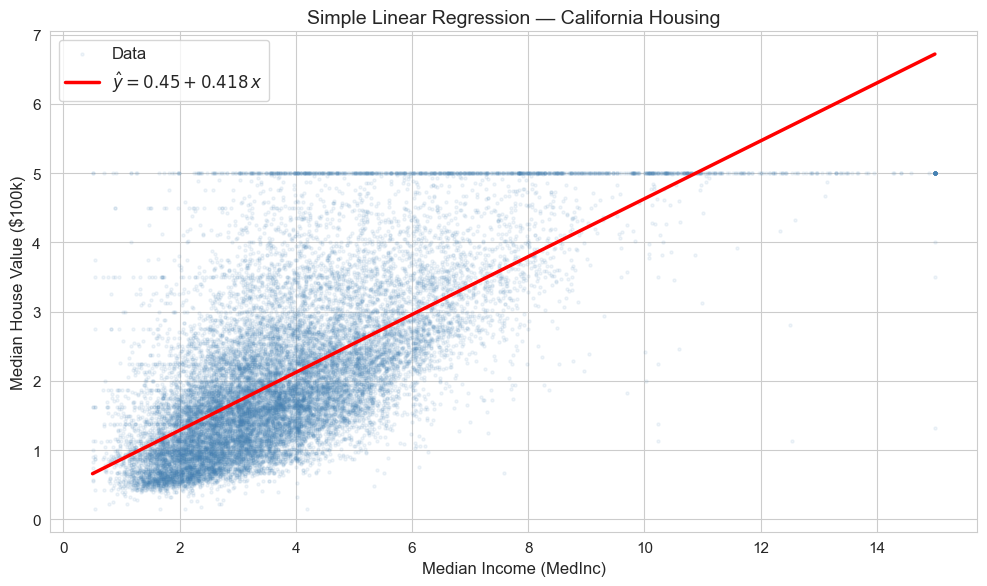

In [65]:
# Plot regression line + data
y_hat_all = reg_simple.predict(x.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x, y, alpha=0.08, s=5, color='steelblue', label='Data')
sort_idx = np.argsort(x)
ax.plot(x[sort_idx], y_hat_all[sort_idx], color='red', linewidth=2.5,
        label=rf'$\hat{{y}} = {beta0_manual:.2f} + {beta1_manual:.3f}\,x$')
ax.set_xlabel('Median Income (MedInc)')
ax.set_ylabel('Median House Value ($100k)')
ax.set_title('Simple Linear Regression — California Housing')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 7. Residuals vs the Error Term

### The Error Term $\varepsilon$ (Unobservable)

$$\varepsilon_i = y_i - (\beta_0 + \beta_1 x_i)$$

This is the *true* deviation from the population regression line.  It depends on the
unknown $\beta_0, \beta_1$, so we **can never compute it**.

### The Residual $e$ (Observable)

$$e_i = y_i - \hat{y}_i = y_i - (\hat{\beta}_0 + \hat{\beta}_1 x_i)$$

This is the deviation from the *fitted* line — fully computable.

### Key Differences

| Property | Error $\varepsilon$ | Residual $e$ |
|----------|-------------------|-------------|
| Observable? | ❌ No | ✅ Yes |
| Sum to zero? | Not necessarily | $\sum e_i = 0$ (always, by construction) |
| Independent? | Yes (by assumption) | No (constrained by $\sum e_i = 0$ and $\sum x_i e_i = 0$) |
| Distribution | $\varepsilon_i \sim N(0, \sigma^2)$ | $e_i$ only *approximately* normal |

We use residuals $e$ as **proxies** for the errors $\varepsilon$ to check model assumptions.

> 💡 **Physicist's Intuition**: The error $\varepsilon$ is like the "true" measurement
> uncertainty — the difference between a measured value and the *exact* physical quantity.
> The residual $e$ is like the difference between a measurement and a *fitted curve*
> through the data.  The fit absorbs some of the error, so residuals underestimate true
> noise.

> ⚠️ **Common Misconception**: "Residuals and errors are the same thing."  They're not!
> Residuals are correlated and constrained; errors are independent.  For large $n$ the
> distinction fades, but for small samples it matters.

In [66]:
# Compute residuals for simple regression
residuals = y - y_hat_all

print(f"Sum of residuals: {residuals.sum():.6e}  (≈ 0 by construction)")
print(f"Sum of x·e:       {np.sum(x * residuals):.6e}  (≈ 0 by OLS normal equations)")
print(f"Mean residual:    {residuals.mean():.6e}")

Sum of residuals: 4.718004e-12  (≈ 0 by construction)
Sum of x·e:       -1.364242e-11  (≈ 0 by OLS normal equations)
Mean residual:    2.285855e-16


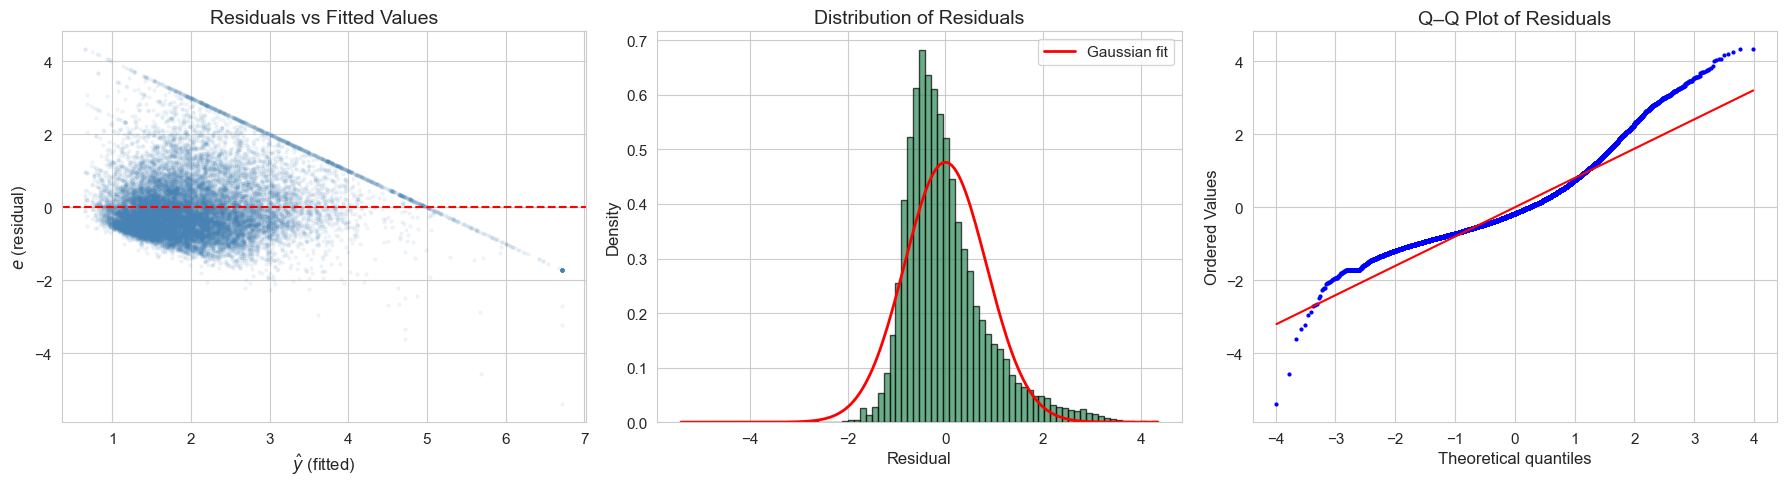

In [67]:
# Residual diagnostic plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residuals vs Fitted
axes[0].scatter(y_hat_all, residuals, alpha=0.06, s=5, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_xlabel(r'$\hat{y}$ (fitted)')
axes[0].set_ylabel('$e$ (residual)')
axes[0].set_title('Residuals vs Fitted Values')

# 2. Histogram of residuals
axes[1].hist(residuals, bins=80, density=True, alpha=0.7, color='seagreen', edgecolor='k')
# Overlay Gaussian
xr = np.linspace(residuals.min(), residuals.max(), 200)
axes[1].plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()),
             'r-', linewidth=2, label='Gaussian fit')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribution of Residuals')
axes[1].legend()

# 3. Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q–Q Plot of Residuals')
axes[2].get_lines()[0].set_markersize(2)

plt.tight_layout()
plt.show()

## 8. Why Is the Error Term Gaussian?

Three complementary arguments justify the Gaussian assumption for $\varepsilon$:

### Argument 1: The Central Limit Theorem (CLT)

The error $\varepsilon$ represents the *aggregate effect of many small, unmodelled influences*:
measurement imprecision, omitted variables, rounding, etc.

The **CLT** says: if $Z = \sum_{k=1}^m W_k$ where $W_k$ are independent with finite
variance, then as $m \to \infty$:

$$\frac{Z - E[Z]}{\sqrt{\text{Var}(Z)}} \xrightarrow{d} \mathcal{N}(0, 1)$$

Since $\varepsilon$ is the sum of many small effects, $\varepsilon \approx \mathcal{N}(0, \sigma^2)$.

### Argument 2: Maximum Entropy

Among all distributions on $(-\infty, \infty)$ with a given mean $\mu$ and variance
$\sigma^2$, the **Gaussian has maximum entropy**:

$$H[f] = -\int_{-\infty}^{\infty} f(x) \ln f(x) \, dx \leq \frac{1}{2}\ln(2\pi e \sigma^2)$$

Equality holds if and only if $f$ is Gaussian.  If all we know about $\varepsilon$ is
its mean (0) and variance ($\sigma^2$), the *least presumptuous* distribution is Gaussian.

### Argument 3: Gauss–Markov & Beyond

The **Gauss–Markov theorem** says OLS is the **Best Linear Unbiased Estimator (BLUE)**
regardless of the error distribution (only need $E[\varepsilon] = 0$, $\text{Var}(\varepsilon) = \sigma^2 I$).

But we need normality for:
- $t$-tests and $F$-tests on coefficients
- Confidence intervals
- Prediction intervals

> 💡 **Physicist's Intuition**: The CLT is the statistical version of *universality*
> in critical phenomena.  Just as many different microscopic interactions lead to the
> same macroscopic phase transition, many different small-effect distributions sum to
> the same Gaussian — the "critical" distribution of the CLT.

> ⚠️ **Common Misconception**: "$Y$ must be normally distributed for linear regression."
> No — only $\varepsilon|X$ must be normal (and only for inference, not for estimation).
> $Y$ itself can be wildly non-normal.

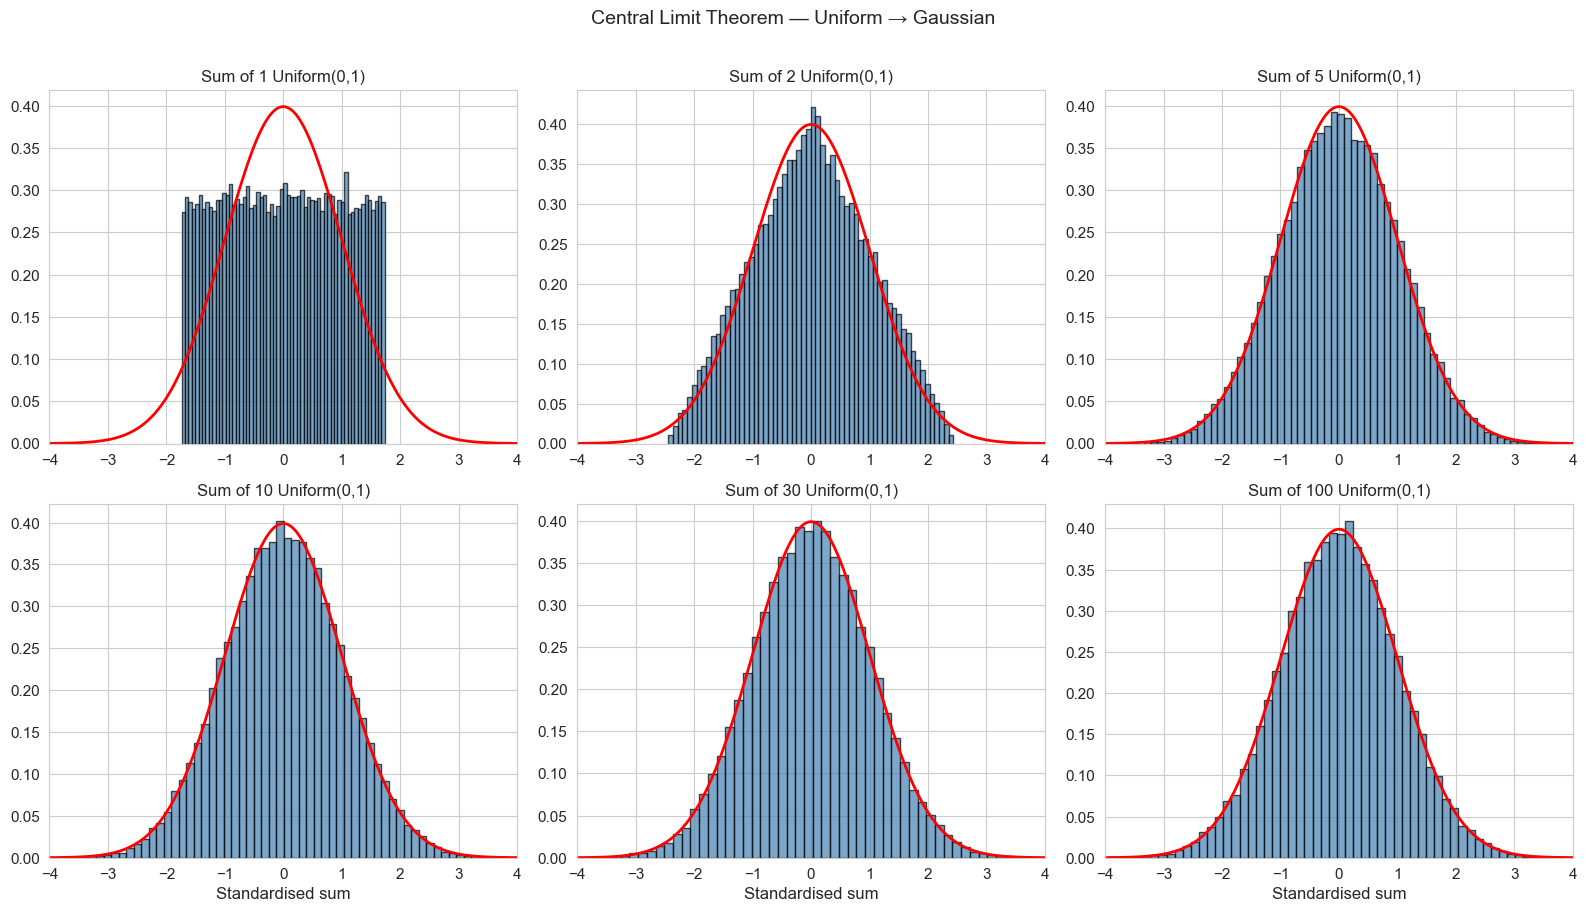

In [68]:
# CLT demonstration: sum of uniforms → Gaussian
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for idx, m in enumerate([1, 2, 5, 10, 30, 100]):
    ax = axes.flat[idx]
    sums = np.sum(np.random.uniform(0, 1, size=(50_000, m)), axis=1)
    # Standardise
    sums_std = (sums - sums.mean()) / sums.std()
    ax.hist(sums_std, bins=60, density=True, alpha=0.7, color='steelblue', edgecolor='k')
    z = np.linspace(-4, 4, 200)
    ax.plot(z, stats.norm.pdf(z), 'r-', linewidth=2)
    ax.set_title(f'Sum of {m} Uniform(0,1)', fontsize=12)
    ax.set_xlim(-4, 4)
    if idx >= 3:
        ax.set_xlabel('Standardised sum')

plt.suptitle('Central Limit Theorem — Uniform → Gaussian', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

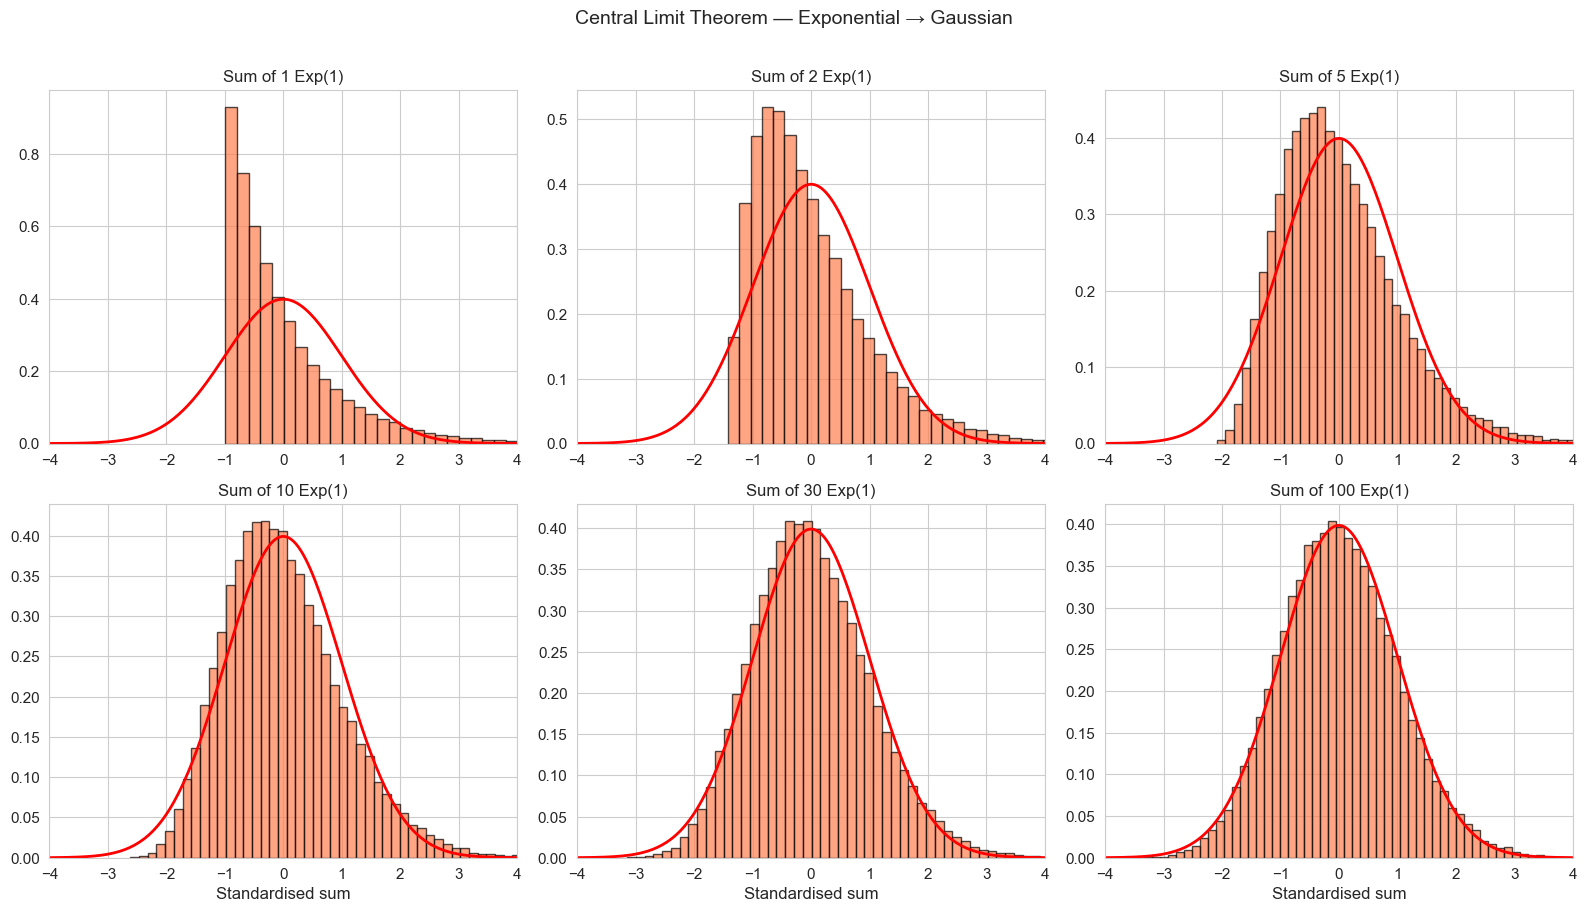

In [69]:
# CLT: sum of exponentials → Gaussian
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for idx, m in enumerate([1, 2, 5, 10, 30, 100]):
    ax = axes.flat[idx]
    sums = np.sum(np.random.exponential(1.0, size=(50_000, m)), axis=1)
    sums_std = (sums - sums.mean()) / sums.std()
    ax.hist(sums_std, bins=60, density=True, alpha=0.7, color='coral', edgecolor='k')
    z = np.linspace(-4, 4, 200)
    ax.plot(z, stats.norm.pdf(z), 'r-', linewidth=2)
    ax.set_title(f'Sum of {m} Exp(1)', fontsize=12)
    ax.set_xlim(-4, 4)
    if idx >= 3:
        ax.set_xlabel('Standardised sum')

plt.suptitle('Central Limit Theorem — Exponential → Gaussian', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 9. The Gaussian Distribution

### The PDF

The probability density function of the Gaussian (normal) distribution is:

$$f(x \,|\, \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

**Why this form?**

1. The $\exp(-x^2)$ ensures rapid decay in the tails.
2. The factor $(x-\mu)^2 / (2\sigma^2)$ makes the width controlled by $\sigma$.
3. The prefactor $1/\sqrt{2\pi\sigma^2}$ normalises the total area to 1.

Equivalently, $-\ln f(x) \propto (x - \mu)^2$, so **minimising negative log-likelihood
is equivalent to minimising squared error** — the deep connection between Gaussian
assumptions and least-squares.

### The 68–95–99.7 Rule

For $X \sim \mathcal{N}(\mu, \sigma^2)$:

| Interval | Probability |
|----------|-------------|
| $\mu \pm 1\sigma$ | 68.27% |
| $\mu \pm 2\sigma$ | 95.45% |
| $\mu \pm 3\sigma$ | 99.73% |

### Standardisation

Any Gaussian can be converted to the **standard normal** $Z \sim \mathcal{N}(0, 1)$:

$$Z = \frac{X - \mu}{\sigma}$$

### Sum of Gaussians

If $X_1 \sim \mathcal{N}(\mu_1, \sigma_1^2)$ and $X_2 \sim \mathcal{N}(\mu_2, \sigma_2^2)$
are independent, then:

$$X_1 + X_2 \sim \mathcal{N}(\mu_1 + \mu_2, \,\sigma_1^2 + \sigma_2^2)$$

This is unique to the Gaussian — it's closed under convolution.

> 💡 **Physicist's Intuition**: The Gaussian is the **fixed point** of the convolution
> operation, much like a thermal equilibrium state is the fixed point of microscopic
> dynamics.  This is fundamentally why the CLT works: repeated convolution of any
> finite-variance distribution converges to the Gaussian fixed point.

> ⚠️ **Common Misconception**: "Most real data is normally distributed."  It rarely is!
> Income, city populations, earthquake magnitudes, and neural network weights are all
> non-Gaussian.  The CLT applies to *sums/averages*, not to raw data.

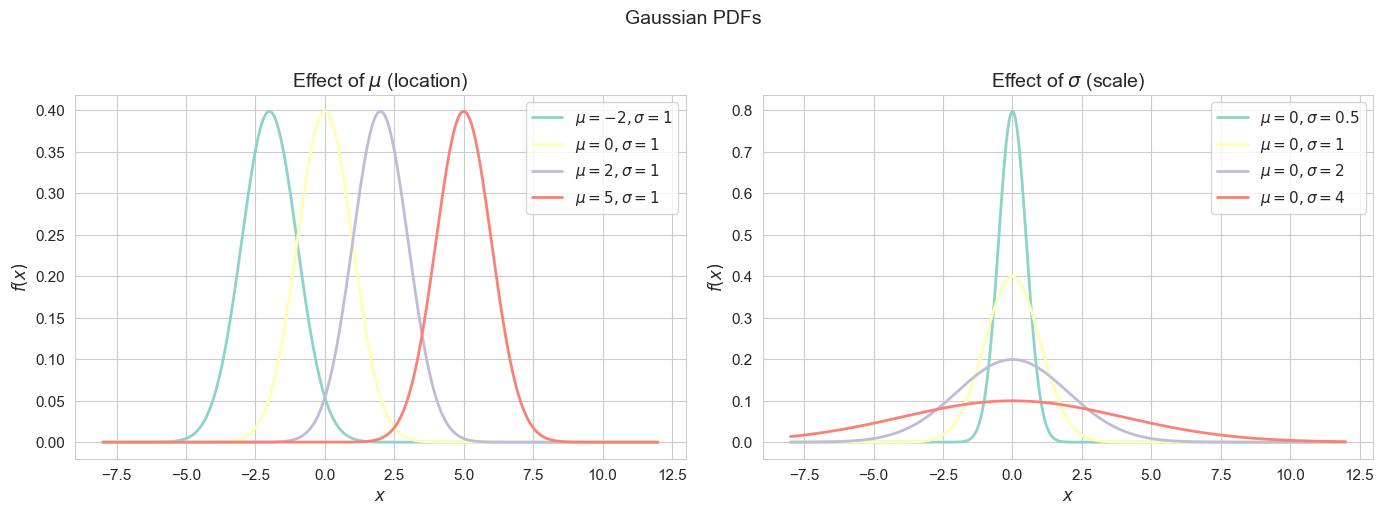

In [70]:
# Plot Gaussian PDFs with different μ, σ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varying μ
x = np.linspace(-8, 12, 500)
for mu in [-2, 0, 2, 5]:
    axes[0].plot(x, stats.norm.pdf(x, mu, 1), linewidth=2, label=rf'$\mu={mu}, \sigma=1$')
axes[0].set_title(r'Effect of $\mu$ (location)')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$f(x)$')
axes[0].legend()

# Varying σ
for sigma in [0.5, 1, 2, 4]:
    axes[1].plot(x, stats.norm.pdf(x, 0, sigma), linewidth=2, label=rf'$\mu=0, \sigma={sigma}$')
axes[1].set_title(r'Effect of $\sigma$ (scale)')
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$f(x)$')
axes[1].legend()

plt.suptitle('Gaussian PDFs', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

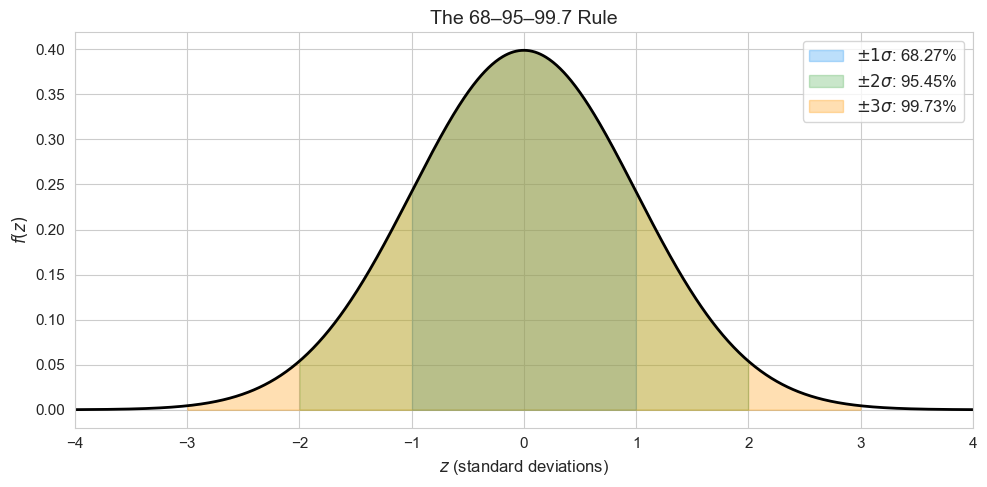

In [71]:
# 68-95-99.7 rule visualisation
fig, ax = plt.subplots(figsize=(10, 5))
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

ax.plot(x, y, 'k-', linewidth=2)

colors = ['#2196F3', '#4CAF50', '#FF9800']
sigmas = [1, 2, 3]
probs = [68.27, 95.45, 99.73]

for s, c, p in zip(sigmas, colors, probs):
    mask = (x >= -s) & (x <= s)
    ax.fill_between(x[mask], y[mask], alpha=0.3, color=c,
                    label=rf'$\pm{s}\sigma$: {p}%')

ax.set_xlabel('$z$ (standard deviations)')
ax.set_ylabel('$f(z)$')
ax.set_title('The 68–95–99.7 Rule')
ax.legend(fontsize=12)
ax.set_xlim(-4, 4)
plt.tight_layout()
plt.show()

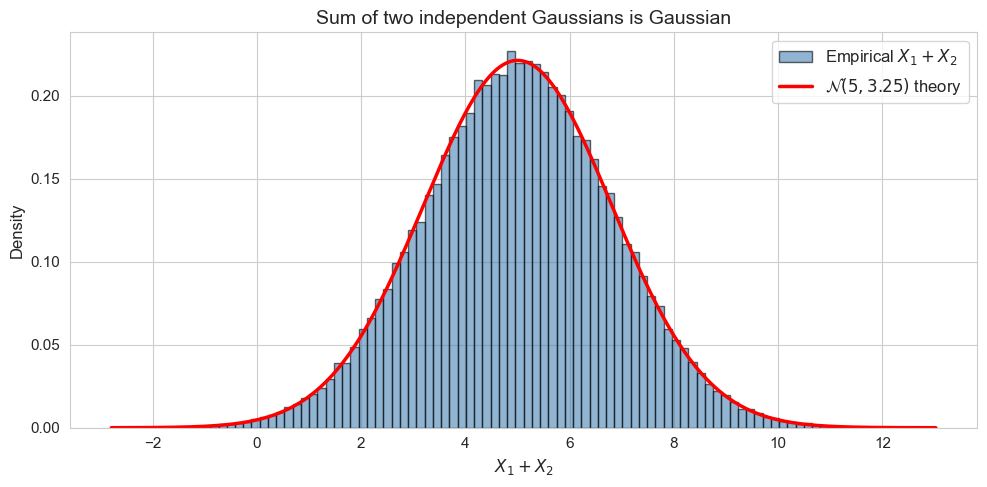

Empirical: mean = 5.002, var = 3.266
Theory:    mean = 5.000,      var = 3.250


In [72]:
# Sum of Gaussians is Gaussian
np.random.seed(42)
X1 = np.random.normal(2, 1, 100_000)     # N(2, 1)
X2 = np.random.normal(3, 1.5, 100_000)   # N(3, 2.25)
S = X1 + X2                              # Should be N(5, 3.25)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(S, bins=100, density=True, alpha=0.6, color='steelblue', edgecolor='k', label='Empirical $X_1+X_2$')
x_plot = np.linspace(S.min(), S.max(), 300)
ax.plot(x_plot, stats.norm.pdf(x_plot, 5, np.sqrt(3.25)), 'r-', linewidth=2.5,
        label=r'$\mathcal{N}(5, 3.25)$ theory')
ax.set_xlabel('$X_1 + X_2$')
ax.set_ylabel('Density')
ax.set_title('Sum of two independent Gaussians is Gaussian')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"Empirical: mean = {S.mean():.3f}, var = {S.var():.3f}")
print(f"Theory:    mean = 5.000,      var = 3.250")

## 10. MSE, MAE, and RMSE

### Mean Squared Error

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2$$

**Why squared errors?**

1. **Differentiability**: $|x|$ has a kink at 0; $x^2$ is smooth everywhere → easier
   optimisation.
2. **Gaussian MLE**: If $\varepsilon \sim \mathcal{N}(0, \sigma^2)$, minimising MSE is
   equivalent to maximising the likelihood.  So MSE is the *natural* loss for Gaussian noise.
3. **Variance decomposition**: $\text{MSE}(\hat{\theta}) = \text{Bias}^2 + \text{Variance}$.

### Root Mean Squared Error

$$\text{RMSE} = \sqrt{\text{MSE}}$$

RMSE has the same *units* as $y$, making it more interpretable.

### Mean Absolute Error

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^n |y_i - \hat{y}_i|$$

* More **robust to outliers** (outliers contribute linearly, not quadratically).
* Minimised by the **median** (whereas MSE is minimised by the mean).
* Corresponds to MLE under **Laplace** (double-exponential) noise.

> 💡 **Physicist's Intuition**: MSE is like the *energy* of a system of springs connecting
> each prediction to its true value (Hooke's law: $E \propto x^2$).  MAE is like the
> *work* done against a constant friction force ($W \propto |x|$).

> ⚠️ **Common Misconception**: "Lower MSE always means a better model."  MSE on training
> data *always* decreases as model complexity increases (just memorise the data).  What
> matters is MSE on *unseen* data — hence train/test splits and cross-validation.

In [73]:
# Compute MSE, RMSE, MAE for Housing regression
mse_val = mean_squared_error(y_test, y_hat)
rmse_val = np.sqrt(mse_val)
mae_val = mean_absolute_error(y_test, y_hat)

print("Metrics for simple regression (MedInc → MedHouseVal):")
print(f"  MSE  = {mse_val:.4f}")
print(f"  RMSE = {rmse_val:.4f}  (in units of $100k)")
print(f"  MAE  = {mae_val:.4f}  (in units of $100k)")

Metrics for simple regression (MedInc → MedHouseVal):
  MSE  = 0.7091
  RMSE = 0.8421  (in units of $100k)
  MAE  = 0.6299  (in units of $100k)


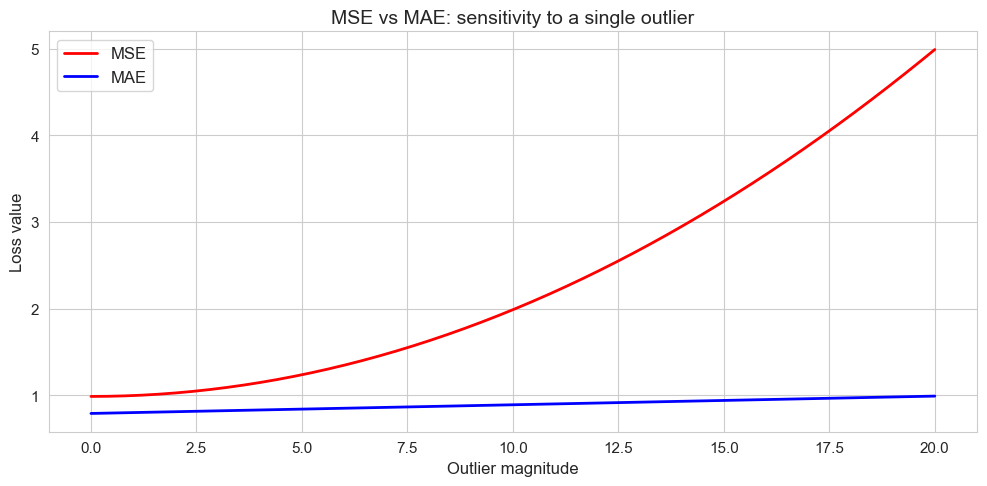

In [74]:
# Visualise: MSE vs MAE sensitivity to outliers
np.random.seed(0)
y_true_demo = np.random.normal(0, 1, 100)
y_pred_demo = np.zeros(100)

outlier_magnitudes = np.linspace(0, 20, 200)
mse_list = []
mae_list = []

for om in outlier_magnitudes:
    y_mod = y_true_demo.copy()
    y_mod[0] = om  # inject one outlier
    mse_list.append(np.mean((y_mod - y_pred_demo)**2))
    mae_list.append(np.mean(np.abs(y_mod - y_pred_demo)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(outlier_magnitudes, mse_list, 'r-', linewidth=2, label='MSE')
ax.plot(outlier_magnitudes, mae_list, 'b-', linewidth=2, label='MAE')
ax.set_xlabel('Outlier magnitude')
ax.set_ylabel('Loss value')
ax.set_title('MSE vs MAE: sensitivity to a single outlier')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 11. $R^2$ — Coefficient of Determination

### Decomposition of Total Variation

$$\underbrace{\sum (y_i - \bar{y})^2}_{\text{SS}_\text{total}} =
  \underbrace{\sum (\hat{y}_i - \bar{y})^2}_{\text{SS}_\text{regression}} +
  \underbrace{\sum (y_i - \hat{y}_i)^2}_{\text{SS}_\text{residual}}$$

### Definition

$$R^2 = 1 - \frac{\text{SS}_\text{res}}{\text{SS}_\text{total}}
     = \frac{\text{SS}_\text{reg}}{\text{SS}_\text{total}}$$

**Interpretation**: the *proportion of variance in $y$ explained by the model*.

### Key Properties

1. $0 \leq R^2 \leq 1$ for models with an intercept fit on training data.
2. **$R^2 = r^2$** for simple linear regression (the square of the Pearson correlation between $x$ and $y$).
3. $R^2$ can be **negative** on test data or for models without an intercept.

### Adjusted $R^2$

$$R^2_\text{adj} = 1 - \frac{(1 - R^2)(n - 1)}{n - p - 1}$$

where $p$ is the number of predictors.  This penalises adding useless predictors.

> 💡 **Physicist's Intuition**: $R^2$ is the "fraction of signal power" in a
> signal-to-noise decomposition.  $\text{SS}_\text{total}$ is total power, $\text{SS}_\text{reg}$
> is signal power, and $\text{SS}_\text{res}$ is noise power.

> ⚠️ **Common Misconception**: "High $R^2$ means a good model."  Not necessarily.
> A polynomial of degree $n-1$ fits $n$ points perfectly ($R^2 = 1$) but generalises
> terribly.  Also, $R^2$ doesn't tell you if the model is *correct* — just that it
> captures variance.

In [75]:
# Compute R² manually and compare with sklearn
y_bar = y_test.mean()
ss_total = np.sum((y_test - y_bar)**2)
ss_res = np.sum((y_test - y_hat)**2)
ss_reg = np.sum((y_hat - y_bar)**2)

r2_manual = 1 - ss_res / ss_total
r2_sklearn = r2_score(y_test, y_hat)
r_pearson = np.corrcoef(X_test.flatten(), y_test)[0, 1]

print(f"SS_total      = {ss_total:.2f}")
print(f"SS_residual   = {ss_res:.2f}")
print(f"SS_regression = {ss_reg:.2f}")
print(f"SS_reg + SS_res = {ss_reg + ss_res:.2f}  (should approx SS_total)")
print()
print(f"R2 (manual)   = {r2_manual:.6f}")
print(f"R2 (sklearn)  = {r2_sklearn:.6f}")
print(f"r (Pearson)   = {r_pearson:.6f}")
print(f"r squared     = {r_pearson**2:.6f}  (should approx R2 for simple regression)")

SS_total      = 5409.37
SS_residual   = 2927.23
SS_regression = 2569.16
SS_reg + SS_res = 5496.39  (should approx SS_total)

R2 (manual)   = 0.458859
R2 (sklearn)  = 0.458859
r (Pearson)   = 0.677502
r squared     = 0.459008  (should approx R2 for simple regression)


In [76]:
# Prove R² = r² for simple regression
# Pearson r between y_test and y_hat
r_yy = np.corrcoef(y_test, y_hat)[0, 1]

print(f"Pearson r(y, ŷ)  = {r_yy:.6f}")
print(f"r²               = {r_yy**2:.6f}")
print(f"R² (sklearn)     = {r2_sklearn:.6f}")
print(f"\nFor simple linear regression: R² = r²(y, ŷ)  ✓")

Pearson r(y, ŷ)  = 0.677502
r²               = 0.459008
R² (sklearn)     = 0.458859

For simple linear regression: R² = r²(y, ŷ)  ✓


## 12. Confidence Intervals and Standard Error

### Standard Error of $\hat{\beta}_1$

Under OLS assumptions, the variance of the slope estimator is:

$$\text{Var}(\hat{\beta}_1) = \frac{\sigma^2}{\sum_{i=1}^n (x_i - \bar{x})^2}$$

Since $\sigma^2$ is unknown, we estimate it with $\hat{\sigma}^2 = \text{RSS}/(n-2)$, giving:

$$\text{SE}(\hat{\beta}_1) = \frac{\hat{\sigma}}{\sqrt{\sum(x_i - \bar{x})^2}}$$

### Confidence Interval

A **95% confidence interval** for $\beta_1$ is:

$$\hat{\beta}_1 \pm t_{n-2, \, 0.025} \cdot \text{SE}(\hat{\beta}_1)$$

**What does "95% CI" actually mean?** (Frequentist interpretation)

If we repeated the entire experiment many times, 95% of the resulting intervals
would contain the true $\beta_1$.  It does **not** mean "there is a 95% probability
that $\beta_1$ is in this interval" — $\beta_1$ is fixed (but unknown), not random.

> 💡 **Physicist's Intuition**: A confidence interval is like an error bar on a
> measurement.  When you report $g = 9.81 \pm 0.02 \, \text{m/s}^2$, you're saying:
> "Given my apparatus and procedure, if I repeated this experiment many times, 95% of
> my intervals would contain the true $g$."

> ⚠️ **Common Misconception**: "95% CI means there's a 95% chance the true value is
> inside."  This is the Bayesian credible interval interpretation, not the frequentist
> CI.  In frequentist statistics, the parameter is fixed and the interval is random.

In [77]:
# Fit OLS with statsmodels for full inference
X_sm = sm.add_constant(housing['MedInc'])
ols_model = sm.OLS(housing['MedHouseVal'], X_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.473
Method:                 Least Squares   F-statistic:                 1.856e+04
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:05:03   Log-Likelihood:                -25623.
No. Observations:               20640   AIC:                         5.125e+04
Df Residuals:                   20638   BIC:                         5.127e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4509      0.013     34.082      0.0

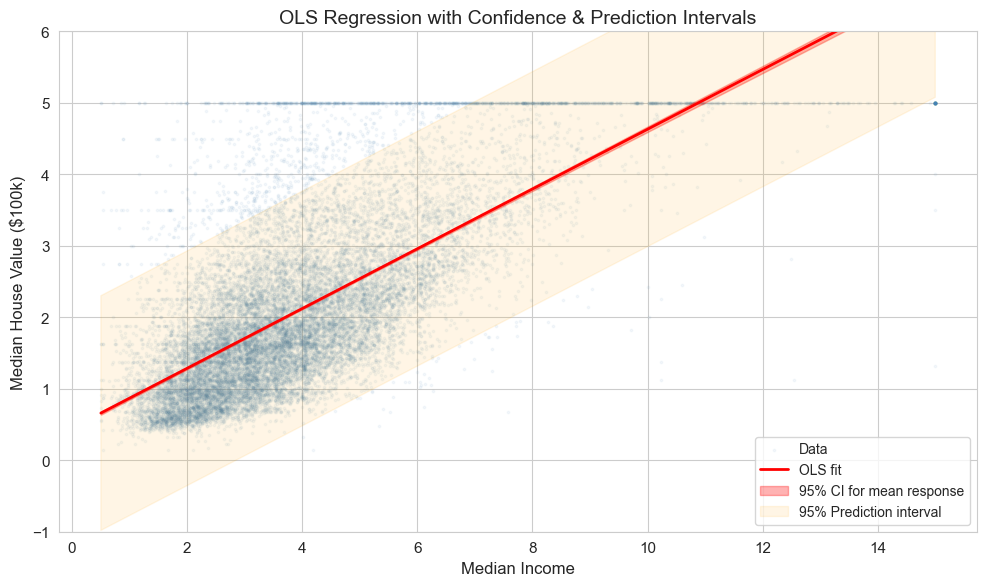

In [78]:
# Visualise confidence interval band around regression line
x_plot = np.linspace(housing['MedInc'].min(), housing['MedInc'].max(), 300)
X_plot_sm = sm.add_constant(x_plot)

predictions = ols_model.get_prediction(X_plot_sm)
pred_summary = predictions.summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(housing['MedInc'], housing['MedHouseVal'], alpha=0.05, s=3, color='steelblue', label='Data')
ax.plot(x_plot, pred_summary['mean'], 'r-', linewidth=2, label='OLS fit')
ax.fill_between(x_plot,
                pred_summary['mean_ci_lower'],
                pred_summary['mean_ci_upper'],
                alpha=0.3, color='red', label='95% CI for mean response')
ax.fill_between(x_plot,
                pred_summary['obs_ci_lower'],
                pred_summary['obs_ci_upper'],
                alpha=0.1, color='orange', label='95% Prediction interval')
ax.set_xlabel('Median Income')
ax.set_ylabel('Median House Value ($100k)')
ax.set_title('OLS Regression with Confidence & Prediction Intervals')
ax.legend(fontsize=10)
ax.set_ylim(-1, 6)
plt.tight_layout()
plt.show()

In [79]:
# Simulate to verify 95% CI coverage
true_beta0, true_beta1, true_sigma = 2.0, 0.5, 1.0
n_sim = 10_000
n_obs = 50
covers = 0

np.random.seed(42)
x_fixed = np.linspace(0, 10, n_obs)

for _ in range(n_sim):
    eps = np.random.normal(0, true_sigma, n_obs)
    y_sim = true_beta0 + true_beta1 * x_fixed + eps
    X_sim = sm.add_constant(x_fixed)
    res = sm.OLS(y_sim, X_sim).fit()
    ci = res.conf_int(alpha=0.05)
    if ci[0, 0] <= true_beta0 <= ci[0, 1]:  # check intercept CI
        covers += 1

print(f"True β₀ = {true_beta0}")
print(f"Coverage of 95% CI for β₀: {covers/n_sim*100:.1f}% ({covers}/{n_sim})")
print(f"(Should be ~95%)")

True β₀ = 2.0
Coverage of 95% CI for β₀: 94.6% (9462/10000)
(Should be ~95%)


## 13. Homoscedasticity vs Heteroscedasticity

### Definitions

- **Homoscedasticity**: $\text{Var}(\varepsilon_i | X_i) = \sigma^2$ for all $i$ — constant variance.
- **Heteroscedasticity**: $\text{Var}(\varepsilon_i | X_i) = \sigma_i^2$ — variance depends on $X$.

### Why It Matters

Under heteroscedasticity:

1. OLS estimates $\hat{\beta}$ are still **unbiased and consistent**.
2. But **standard errors are wrong** → invalid $t$-tests, $F$-tests, confidence intervals.
3. OLS is no longer **efficient** — Weighted Least Squares (WLS) or Generalised Least
   Squares (GLS) would be better.

### Detection

- **Visual**: Plot residuals vs fitted values.  A "funnel" or "fan" shape indicates heteroscedasticity.
- **Formal**: Breusch–Pagan test, White test.

> 💡 **Physicist's Intuition**: Homoscedasticity is like having *uniform measurement
> precision* across your entire range.  Heteroscedasticity is like a detector whose
> noise increases with signal strength (common in photon counting: $\sigma \propto \sqrt{N}$).

> ⚠️ **Common Misconception**: "Heteroscedasticity means the model is wrong."  Not
> necessarily — the *mean* function might be correct, but the *noise* structure isn't
> constant.  Use robust standard errors (HC0–HC3) rather than changing the model.

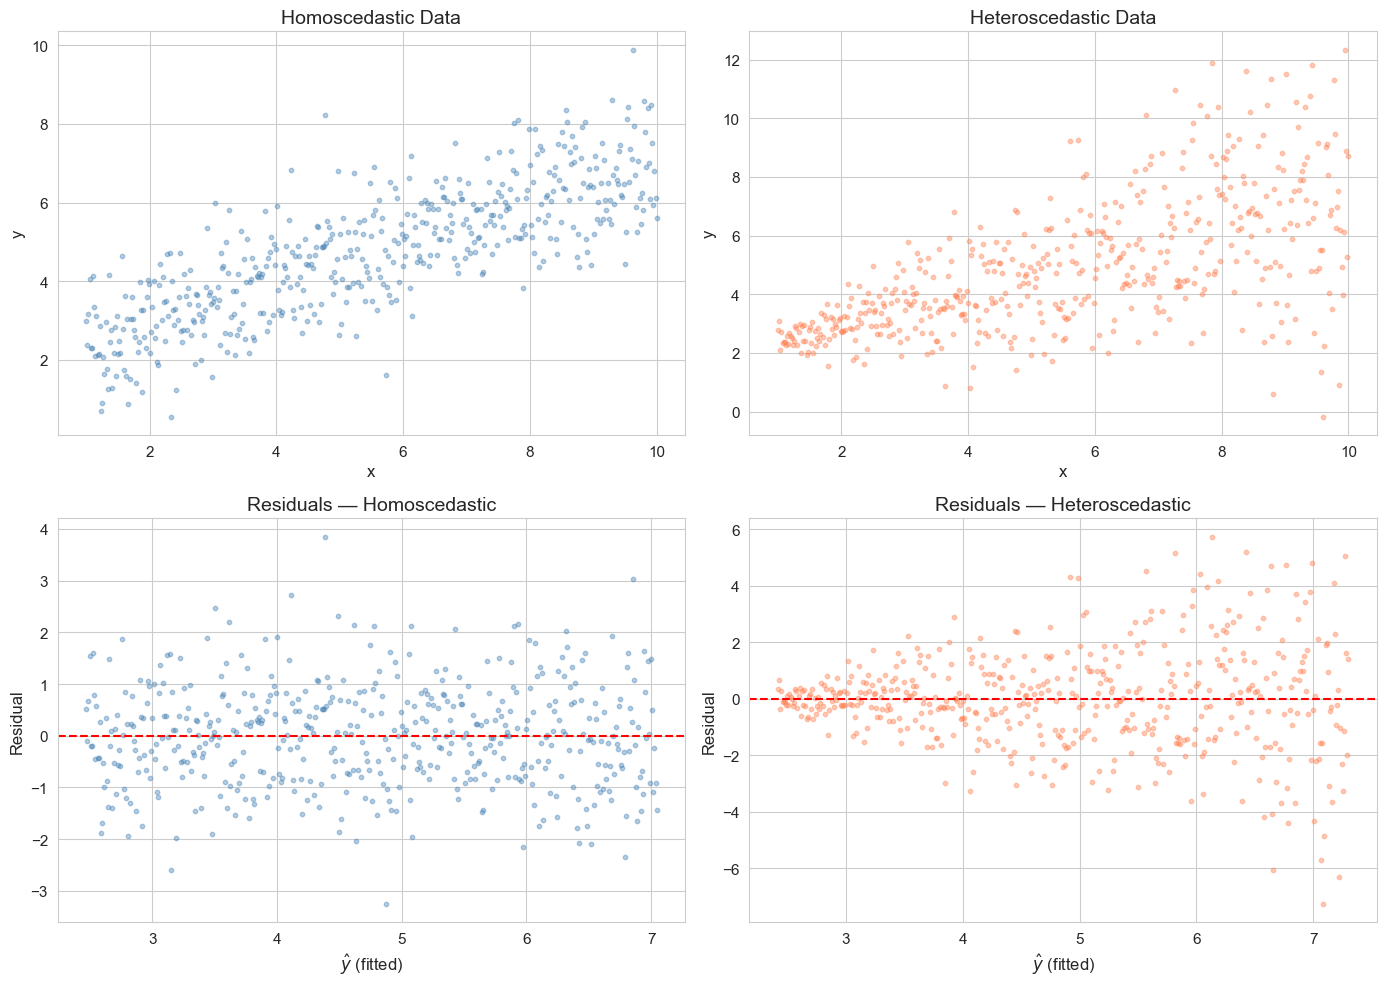

In [80]:
# Demonstrate homoscedastic vs heteroscedastic data
np.random.seed(42)
n = 500
x_demo = np.linspace(1, 10, n)

# Homoscedastic
y_homo = 2 + 0.5 * x_demo + np.random.normal(0, 1, n)

# Heteroscedastic (variance grows with x)
y_hetero = 2 + 0.5 * x_demo + np.random.normal(0, 0.3 * x_demo, n)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter plots
axes[0, 0].scatter(x_demo, y_homo, alpha=0.4, s=10, color='steelblue')
axes[0, 0].set_title('Homoscedastic Data')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('y')

axes[0, 1].scatter(x_demo, y_hetero, alpha=0.4, s=10, color='coral')
axes[0, 1].set_title('Heteroscedastic Data')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('y')

# Residual plots
for idx, (y_data, color, title) in enumerate([
    (y_homo, 'steelblue', 'Residuals — Homoscedastic'),
    (y_hetero, 'coral', 'Residuals — Heteroscedastic')
]):
    X_d = sm.add_constant(x_demo)
    fit = sm.OLS(y_data, X_d).fit()
    resids = fit.resid
    axes[1, idx].scatter(fit.fittedvalues, resids, alpha=0.4, s=10, color=color)
    axes[1, idx].axhline(0, color='red', linewidth=1.5, linestyle='--')
    axes[1, idx].set_title(title)
    axes[1, idx].set_xlabel(r'$\hat{y}$ (fitted)')
    axes[1, idx].set_ylabel('Residual')

plt.tight_layout()
plt.show()

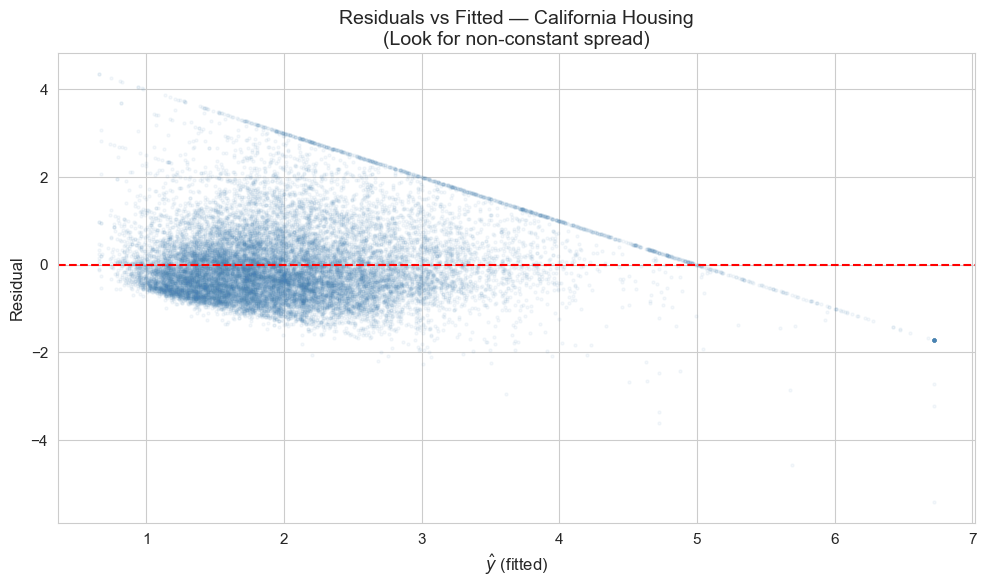

Breusch-Pagan test statistic = 138.86
p-value                      = 4.72e-32
Reject H₀ (homoscedasticity) at α=0.05? Yes ✗


In [81]:
# Check Housing regression residuals for heteroscedasticity
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_hat_all, residuals, alpha=0.05, s=5, color='steelblue')
ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel(r'$\hat{y}$ (fitted)')
ax.set_ylabel('Residual')
ax.set_title('Residuals vs Fitted — California Housing\n(Look for non-constant spread)')
plt.tight_layout()
plt.show()

# Breusch-Pagan test
from statsmodels.stats.diagnostic import het_breuschpagan
bp_stat, bp_pval, _, _ = het_breuschpagan(ols_model.resid, ols_model.model.exog)
print(f"Breusch-Pagan test statistic = {bp_stat:.2f}")
print(f"p-value                      = {bp_pval:.2e}")
print(f"Reject H₀ (homoscedasticity) at α=0.05? {'Yes ✗' if bp_pval < 0.05 else 'No ✓'}")

## 14. Putting It All Together

Let's perform a complete OLS regression analysis on the California Housing data,
using **all features**, and systematically check every assumption.

### The Full Checklist

1. **Linearity**: relationship between $X$ and $E[Y|X]$ is linear
2. **Independence**: observations are independent
3. **Normality**: errors are normally distributed
4. **Homoscedasticity**: constant error variance
5. **No multicollinearity**: predictors are not too correlated

These are sometimes remembered as **LINE** (Linearity, Independence, Normality,
Equal variance).

In [82]:
# Full OLS regression with all Housing features
X_full = sm.add_constant(housing.drop(columns='MedHouseVal'))
y_full = housing['MedHouseVal']

full_model = sm.OLS(y_full, X_full).fit()
print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                     3970.
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:05:05   Log-Likelihood:                -22624.
No. Observations:               20640   AIC:                         4.527e+04
Df Residuals:                   20631   BIC:                         4.534e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -36.9419      0.659    -56.067      0.0

In [83]:
# Interpret the model
print("=" * 60)
print("INTERPRETATION GUIDE")
print("=" * 60)
print(f"\nR² = {full_model.rsquared:.4f}")
print(f"  → The model explains {full_model.rsquared*100:.1f}% of the variance in MedHouseVal.")
print(f"\nAdj. R² = {full_model.rsquared_adj:.4f}")
print(f"  → Adjusted for {len(full_model.params)-1} predictors (penalises complexity).")
print(f"\nF-statistic = {full_model.fvalue:.1f}, p = {full_model.f_pvalue:.2e}")
print(f"  → At least one predictor is significantly related to the target.")

print(f"\nCoefficients:")
for name, coef, pval in zip(full_model.params.index, full_model.params, full_model.pvalues):
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
    print(f"  {name:15s}: {coef:+.4f}  (p={pval:.4e}) {sig}")

print(f"\nDurbin-Watson = {sm.stats.stattools.durbin_watson(full_model.resid):.3f}")
print(f"  (≈2 means no autocorrelation; <1 or >3 is concerning)")

INTERPRETATION GUIDE

R² = 0.6062
  → The model explains 60.6% of the variance in MedHouseVal.

Adj. R² = 0.6061
  → Adjusted for 8 predictors (penalises complexity).

F-statistic = 3970.4, p = 0.00e+00
  → At least one predictor is significantly related to the target.

Coefficients:
  const          : -36.9419  (p=0.0000e+00) ***
  MedInc         : +0.4367  (p=0.0000e+00) ***
  HouseAge       : +0.0094  (p=3.5055e-98) ***
  AveRooms       : -0.1073  (p=1.0263e-73) ***
  AveBedrms      : +0.6451  (p=6.7257e-115) ***
  Population     : -0.0000  (p=4.0245e-01) 
  AveOccup       : -0.0038  (p=8.3037e-15) ***
  Latitude       : -0.4213  (p=0.0000e+00) ***
  Longitude      : -0.4345  (p=0.0000e+00) ***

Durbin-Watson = 0.885
  (≈2 means no autocorrelation; <1 or >3 is concerning)


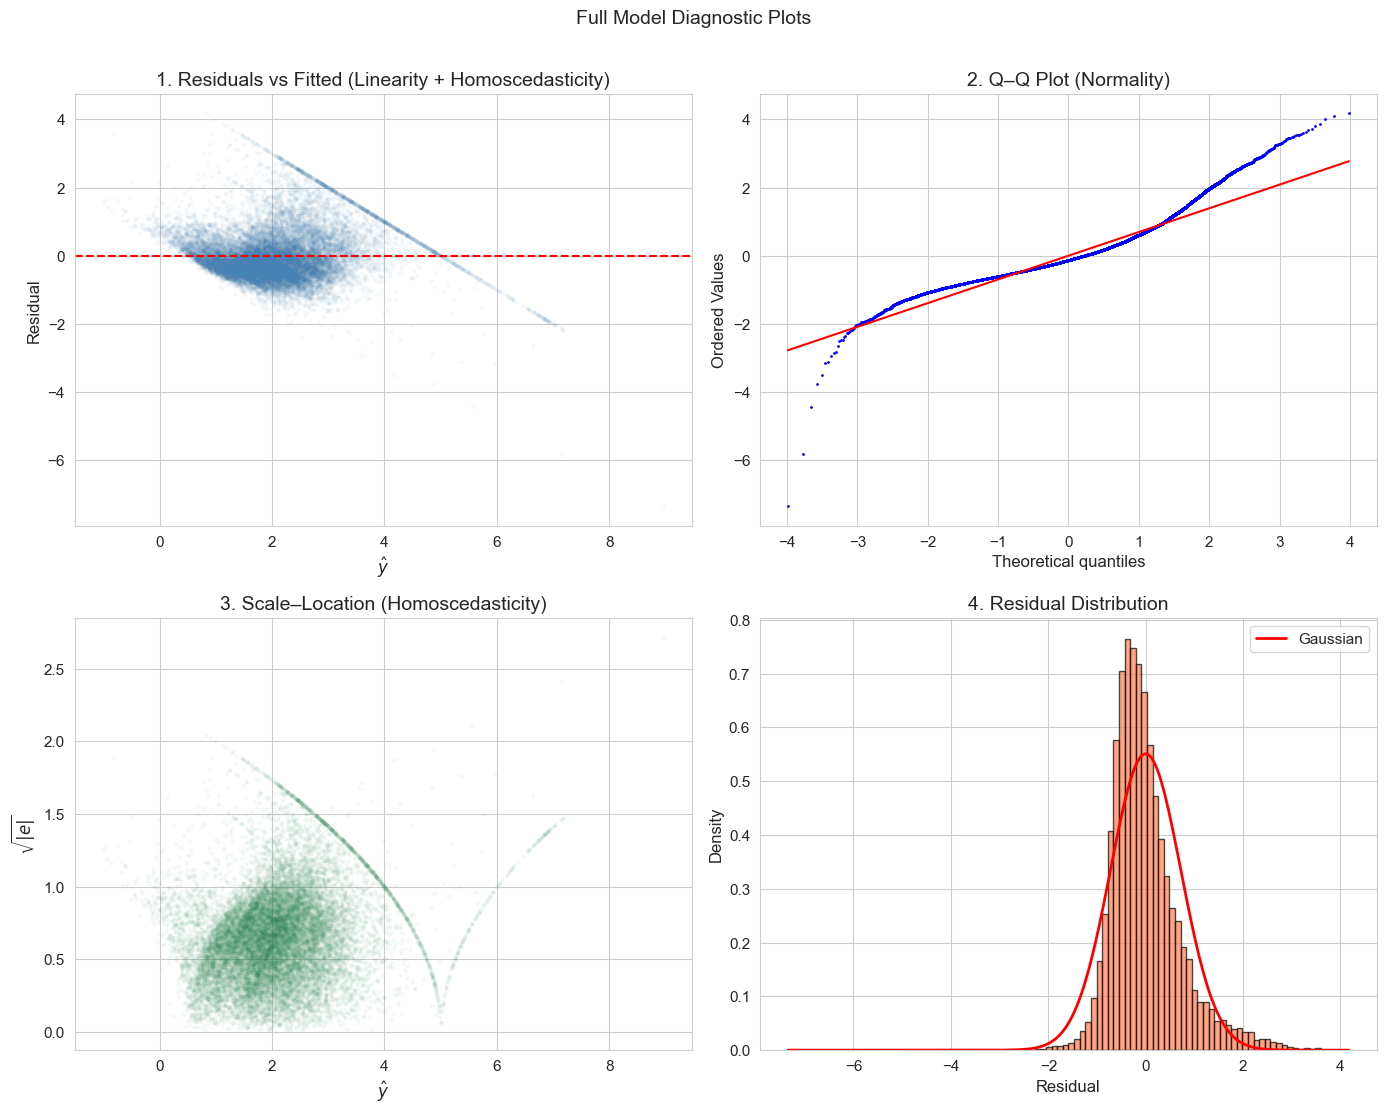

In [84]:
# Assumption checking: comprehensive diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
full_resid = full_model.resid
full_fitted = full_model.fittedvalues

# 1. Residuals vs Fitted
axes[0, 0].scatter(full_fitted, full_resid, alpha=0.03, s=5, color='steelblue')
axes[0, 0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0, 0].set_xlabel(r'$\hat{y}$')
axes[0, 0].set_ylabel('Residual')
axes[0, 0].set_title('1. Residuals vs Fitted (Linearity + Homoscedasticity)')

# 2. Q-Q plot (Normality)
stats.probplot(full_resid, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('2. Q–Q Plot (Normality)')
axes[0, 1].get_lines()[0].set_markersize(1)

# 3. Scale-Location plot
axes[1, 0].scatter(full_fitted, np.sqrt(np.abs(full_resid)), alpha=0.03, s=5, color='seagreen')
axes[1, 0].set_xlabel(r'$\hat{y}$')
axes[1, 0].set_ylabel(r'$\sqrt{|e|}$')
axes[1, 0].set_title('3. Scale–Location (Homoscedasticity)')

# 4. Histogram of residuals
axes[1, 1].hist(full_resid, bins=100, density=True, alpha=0.7, color='coral', edgecolor='k')
xh = np.linspace(full_resid.min(), full_resid.max(), 300)
axes[1, 1].plot(xh, stats.norm.pdf(xh, full_resid.mean(), full_resid.std()),
                'r-', linewidth=2, label='Gaussian')
axes[1, 1].set_xlabel('Residual')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('4. Residual Distribution')
axes[1, 1].legend()

plt.suptitle('Full Model Diagnostic Plots', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [85]:
# Multicollinearity check: Variance Inflation Factors
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = housing.drop(columns='MedHouseVal')
vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print("Variance Inflation Factors (VIF > 10 suggests multicollinearity):\n")
for _, row in vif_data.iterrows():
    flag = " ⚠️" if row['VIF'] > 10 else " ✓"
    print(f"  {row['Feature']:15s}: {row['VIF']:8.2f}{flag}")

Variance Inflation Factors (VIF > 10 suggests multicollinearity):

  Longitude      :   633.71 ⚠️
  Latitude       :   559.87 ⚠️
  AveRooms       :    45.99 ⚠️
  AveBedrms      :    43.59 ⚠️
  MedInc         :    11.51 ⚠️
  HouseAge       :     7.20 ✓
  Population     :     2.94 ✓
  AveOccup       :     1.10 ✓


In [86]:
# Final metrics
y_pred_full = full_model.predict(X_full)

print("=" * 50)
print("FULL MODEL PERFORMANCE")
print("=" * 50)
print(f"  R²        = {r2_score(y_full, y_pred_full):.4f}")
print(f"  Adj. R²   = {full_model.rsquared_adj:.4f}")
print(f"  MSE       = {mean_squared_error(y_full, y_pred_full):.4f}")
print(f"  RMSE      = {np.sqrt(mean_squared_error(y_full, y_pred_full)):.4f}")
print(f"  MAE       = {mean_absolute_error(y_full, y_pred_full):.4f}")
print("=" * 50)

FULL MODEL PERFORMANCE
  R²        = 0.6062
  Adj. R²   = 0.6061
  MSE       = 0.5243
  RMSE      = 0.7241
  MAE       = 0.5312


---

## Summary

| Concept | Key Formula | Section |
|---------|------------|---------|
| Sample mean | $\bar{x} = \frac{1}{n}\sum x_i$ | §2 |
| Estimator (hat) | $\hat{\theta}$: estimated from data | §3 |
| Sample variance | $s^2 = \frac{1}{n-1}\sum(x_i - \bar{x})^2$ | §4 |
| Pearson $r$ | $r = \text{Cov}(X,Y)/(\sigma_X \sigma_Y)$ | §5 |
| OLS slope | $\hat{\beta}_1 = \text{Cov}(X,Y)/\text{Var}(X)$ | §6 |
| Residual vs error | $e = y - \hat{y}$ vs $\varepsilon = y - (\beta_0 + \beta_1 x)$ | §7 |
| CLT | $\bar{X}_n \xrightarrow{d} \mathcal{N}(\mu, \sigma^2/n)$ | §8 |
| Gaussian PDF | $f(x) = \frac{1}{\sqrt{2\pi\sigma^2}}e^{-(x-\mu)^2/(2\sigma^2)}$ | §9 |
| MSE | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | §10 |
| $R^2$ | $1 - \text{SS}_\text{res}/\text{SS}_\text{total}$ | §11 |
| Confidence interval | $\hat{\beta} \pm t \cdot \text{SE}$ | §12 |
| Homoscedasticity | $\text{Var}(\varepsilon|X) = \sigma^2 = \text{const}$ | §13 |

**Next notebook**: Multiple regression, matrix formulation, gradient descent.